<a href="https://colab.research.google.com/github/niranjan2399/ML-and-PyTorch/blob/main/pytorch_training_mechanics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression

In [ ]:
import torch

In [ ]:
x_data = torch.linspace(1, 10, 100)
y_data = 3 * x_data + 7 + torch.randn(100) * 0.5

In [ ]:
w = torch.tensor(0.1, requires_grad=True)
b = torch.tensor(0.1, requires_grad=True)

learning_rate = 0.005

for epoch in range(200):
  y_pred = w * x_data + b
  loss = ((y_pred - y_data) ** 2).mean()
  print(loss)

  loss.backward()
  with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

  w.grad.zero_()
  b.grad.zero_()
  pass

print(f"w = {w.item():.4f}, b = {b.item():.4f}")

tensor(578.8574, grad_fn=<MeanBackward0>)
tensor(227.3328, grad_fn=<MeanBackward0>)
tensor(91.9944, grad_fn=<MeanBackward0>)
tensor(39.8789, grad_fn=<MeanBackward0>)
tensor(19.8008, grad_fn=<MeanBackward0>)
tensor(12.0559, grad_fn=<MeanBackward0>)
tensor(9.0588, grad_fn=<MeanBackward0>)
tensor(7.8895, grad_fn=<MeanBackward0>)
tensor(7.4238, grad_fn=<MeanBackward0>)
tensor(7.2291, grad_fn=<MeanBackward0>)
tensor(7.1388, grad_fn=<MeanBackward0>)
tensor(7.0887, grad_fn=<MeanBackward0>)
tensor(7.0541, grad_fn=<MeanBackward0>)
tensor(7.0256, grad_fn=<MeanBackward0>)
tensor(6.9994, grad_fn=<MeanBackward0>)
tensor(6.9743, grad_fn=<MeanBackward0>)
tensor(6.9495, grad_fn=<MeanBackward0>)
tensor(6.9250, grad_fn=<MeanBackward0>)
tensor(6.9006, grad_fn=<MeanBackward0>)
tensor(6.8763, grad_fn=<MeanBackward0>)
tensor(6.8521, grad_fn=<MeanBackward0>)
tensor(6.8280, grad_fn=<MeanBackward0>)
tensor(6.8040, grad_fn=<MeanBackward0>)
tensor(6.7801, grad_fn=<MeanBackward0>)
tensor(6.7563, grad_fn=<MeanBack

#Neural Networks + ReLU

In [ ]:
import torch
import torch.nn as nn

x_data = torch.linspace(0, 10, 200).unsqueeze(1)
y_data = torch.sin(x_data) + torch.randn(200, 1) * 0.1

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for epoch in range(500):
    y_pred = model(x_data)
    loss = loss_fn(y_pred, y_data)
    print(loss)
    loss.backward()

    optimizer.step()
    optimizer.zero_grad()
    pass

tensor(0.4752, grad_fn=<MseLossBackward0>)
tensor(5.4748, grad_fn=<MseLossBackward0>)
tensor(2.7969, grad_fn=<MseLossBackward0>)
tensor(0.7761, grad_fn=<MseLossBackward0>)
tensor(0.4877, grad_fn=<MseLossBackward0>)
tensor(0.6721, grad_fn=<MseLossBackward0>)
tensor(0.5775, grad_fn=<MseLossBackward0>)
tensor(0.4724, grad_fn=<MseLossBackward0>)
tensor(0.4779, grad_fn=<MseLossBackward0>)
tensor(0.5177, grad_fn=<MseLossBackward0>)
tensor(0.5024, grad_fn=<MseLossBackward0>)
tensor(0.4740, grad_fn=<MseLossBackward0>)
tensor(0.4605, grad_fn=<MseLossBackward0>)
tensor(0.4694, grad_fn=<MseLossBackward0>)
tensor(0.4743, grad_fn=<MseLossBackward0>)
tensor(0.4707, grad_fn=<MseLossBackward0>)
tensor(0.4657, grad_fn=<MseLossBackward0>)
tensor(0.4623, grad_fn=<MseLossBackward0>)
tensor(0.4604, grad_fn=<MseLossBackward0>)
tensor(0.4594, grad_fn=<MseLossBackward0>)
tensor(0.4596, grad_fn=<MseLossBackward0>)
tensor(0.4600, grad_fn=<MseLossBackward0>)
tensor(0.4580, grad_fn=<MseLossBackward0>)
tensor(0.45

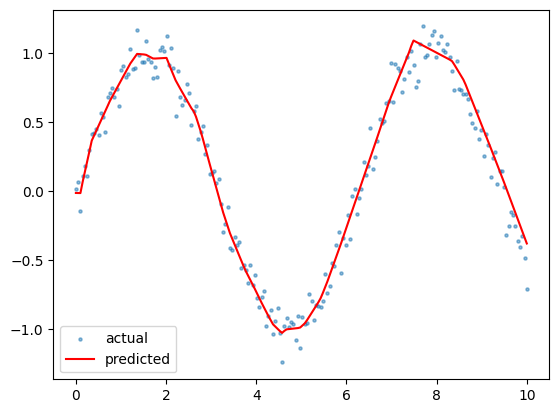

In [ ]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    predictions = model(x_data)

plt.scatter(x_data.numpy(), y_data.numpy(), s=5, label="actual", alpha=0.5)
plt.plot(x_data.numpy(), predictions.numpy(), color="red", label="predicted")
plt.legend()
plt.show()

#Text Classifier

In [1]:
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.utils.data import DataLoader
from collections import Counter

dataset = load_dataset("ag_news")
train_data = dataset["train"]
test_data = dataset["test"]

print(f"Labels: {set(train_data['label'])}")
print(f"Train size: {len(train_data)}, Test size: {len(test_data)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Labels: {0, 1, 2, 3}
Train size: 120000, Test size: 7600


In [2]:
def tokenize(text):
  return text.lower().split()

counter = Counter()
for item in train_data:
  counter.update(tokenize(item['text']))

vocab = {"<unk>": 0}
for word, count in counter.items():
  if count > 5:
    vocab[word] = len(vocab)

print(f"Vocab size: {len(vocab)}")

Vocab size: 35148


In [3]:
def text_to_indices(text):
  return [vocab.get(w, 0) for w in tokenize(text)]

def collate_batch(batch):
  labels, texts, offsets = [], [], [0]

  for item in batch:
    labels.append(item["label"])
    indices = torch.tensor(text_to_indices(item["text"]), dtype = torch.long)
    texts.append(indices)
    offsets.append(len(offsets))

  labels = torch.tensor(labels, dtype = torch.long)
  texts = torch.cat(texts)
  offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)

  return labels, texts, offsets

train_loader = DataLoader(train_data, batch_size = 32, shuffle = True, collate_fn=collate_batch)
test_loader = DataLoader(test_data, batch_size = 32, shuffle = True, collate_fn=collate_batch)

In [4]:
class TextClassifier(nn.Module):
  def __init__(self, vocab_size, embed_dim, num_classes):
    super().__init__()

    self.embedding = nn.EmbeddingBag(vocab_size, embed_dim)
    self.net = nn.Linear(embed_dim, num_classes)

  def forward(self, text, offsets):
    embedded = self.embedding(text, offsets)
    return self.net(embedded)

In [ ]:
model = TextClassifier(vocab_size=len(vocab), embed_dim=128, num_classes=4)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(10):
  model.train()
  total_loss = 0
  correct = 0
  total = 0

  for labels, text, offsets in train_loader:
    predictions = model(text, offsets)
    loss = loss_fn(predictions, labels)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    total_loss += loss
    correct += (predictions.argmax(dim=1) == labels).sum().item()
    total += labels.size(0)

  print(f"Epoch {epoch}: Loss={total_loss/total:.4f}, Accuracy={correct/total:.4f}")
